In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [2]:
fits_data = []
for i in range(1, 6):
    filename = f"M13_000{i}.fits"
    with fits.open(filename) as hdul:
        header = hdul[0].header
        data   = hdul[0].data
        fits_data.append(data)

In [3]:
print(f"Loaded {len(fits_data)} images")
print(f"Each image shape: {fits_data[0].shape}")

Loaded 5 images
Each image shape: (1040, 1392)


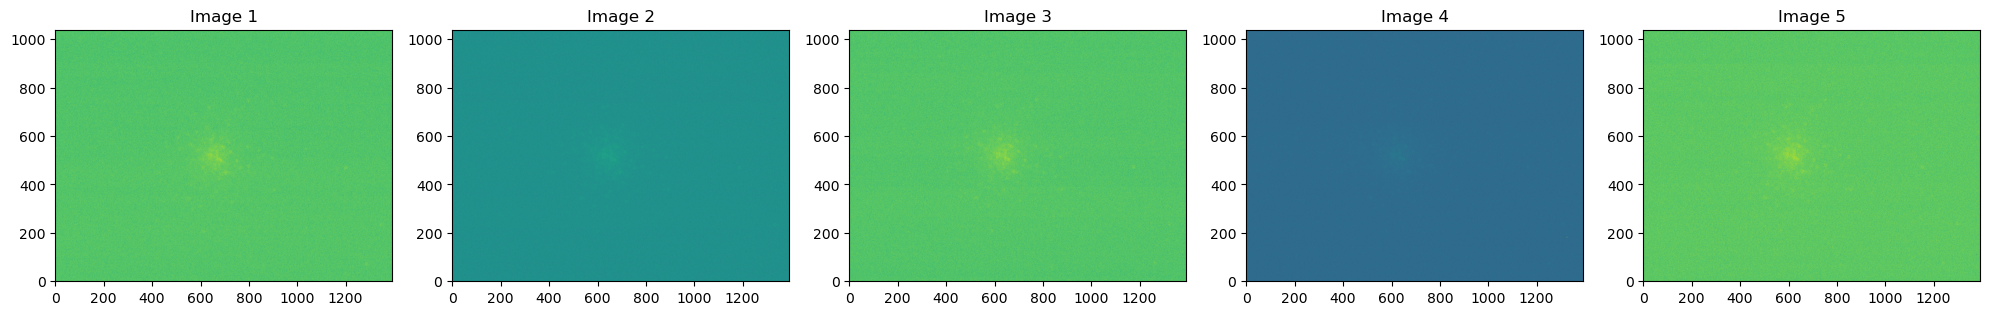

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    ax.imshow(fits_data[i], origin="lower")
    ax.set_title(f"Image {i+1}")
plt.tight_layout()
plt.show()

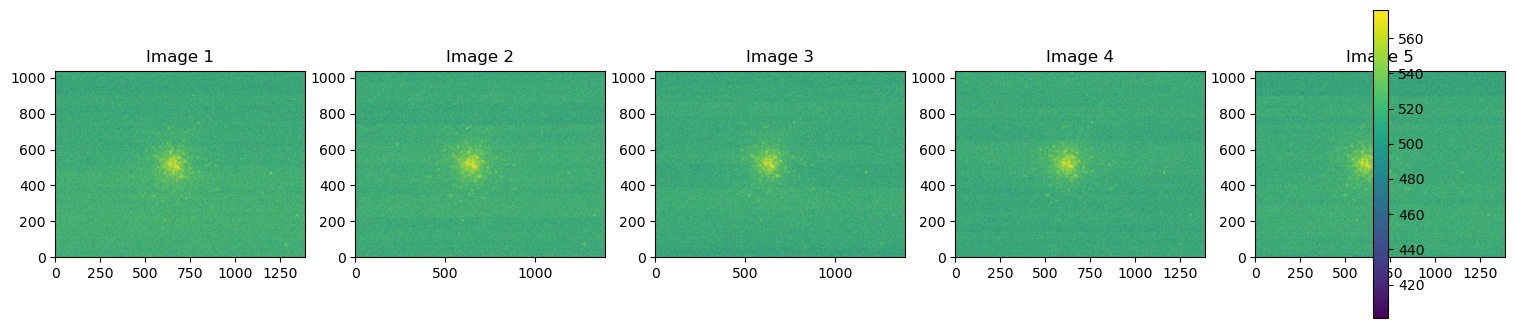

In [5]:
all_pixels = np.concatenate([d.ravel() for d in fits_data])
vmin = np.percentile(all_pixels, 1)
vmax = np.percentile(all_pixels, 99)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    im = ax.imshow(fits_data[i], origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(f"Image {i+1}")
plt.colorbar(im, ax=axes.tolist())
plt.subplots_adjust(right=0.85)
plt.show()

In [6]:
# In the first set each image auto-scales independently, so they all look similarly bright
# even if the actual pixel values differ. In the second set with a shared scale, real 
# brightness differences between exposures are visible, faint stars become comparable 
# across all frames, and the colorbar gives you a concrete reference for what the pixel 
# values actually mean.

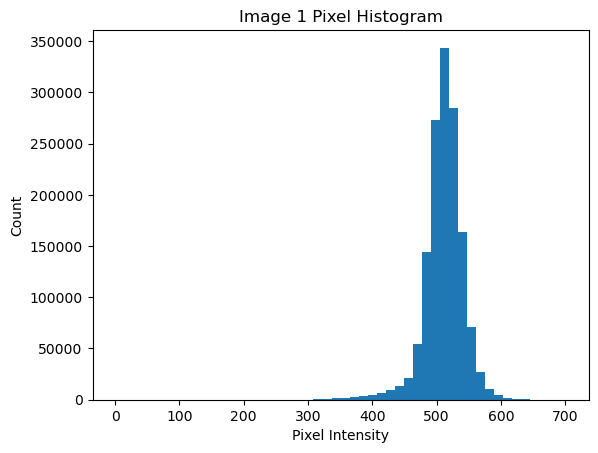

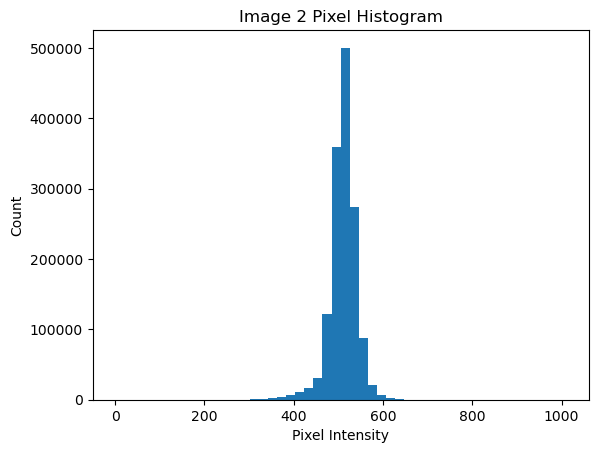

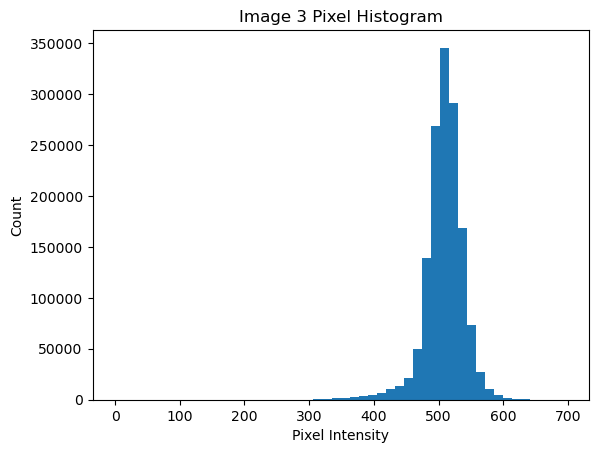

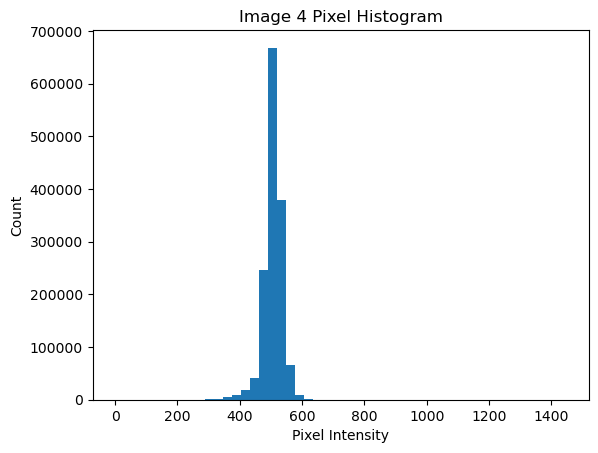

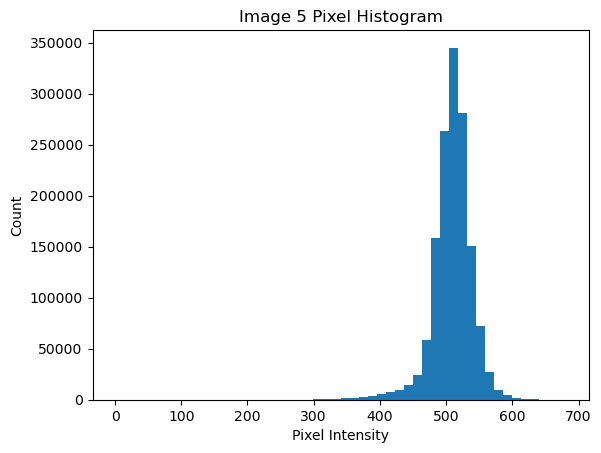

In [7]:
for i, data in enumerate(fits_data):
    plt.figure()
    plt.hist(data.ravel(), bins=50)
    plt.title(f"Image {i+1} Pixel Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Count")
    plt.show()

In [8]:
# 2.
#    a. X-axis and Y-axis
# X-axis: Pixel intensity, the raw brightness value of each pixel from the detector (in ADU, Analog-to-Digital Units)
# Y-axis: Count, the number of pixels at that intensity level

#   b. The full range of pixel intensity values is split into 50 equally spaced intervals. 
# Each bar shows how many pixels fall within that interval. Fewer bins = broader/smoother 
# bars, more bins = finer deta

#   c. The vast majority of pixels sit at a low intensity value representing the dark 
# background sky. The histogram will have a tall narrow peak on the left because most of 
# the image is empty sky, not stars.

#   d. Ignoring the bright star outliers on the right, the main background peak is quite 
# narrow, which spread over roughly 50–100 intensity units. This tightness is expected 
# because the sky background is fairly uniform across the image.

#   e. Mean and Median for each image
for i, data in enumerate(fits_data):
    print(f"Image {i+1} — Median: {np.median(data):.2f}, Mean: {np.mean(data):.2f}")

Image 1 — Median: 512.00, Mean: 510.47
Image 2 — Median: 511.00, Mean: 509.75
Image 3 — Median: 510.00, Mean: 508.05
Image 4 — Median: 509.00, Mean: 507.91
Image 5 — Median: 510.00, Mean: 508.79


In [9]:
# 3.4 Combine and Normalize Images
stack = np.array(fits_data)
combined_image = np.median(stack, axis=0)
print(f"Combined image median pixel intensity: {np.median(combined_image):.2f}")

Combined image median pixel intensity: 510.00


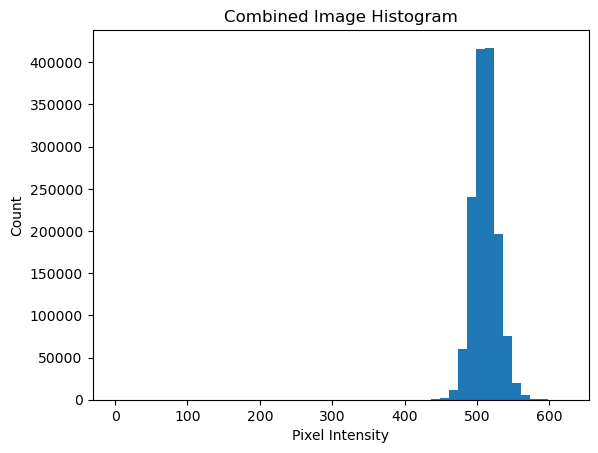

In [10]:
plt.hist(combined_image.ravel(), bins=50)
plt.title("Combined Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Count")
plt.show()

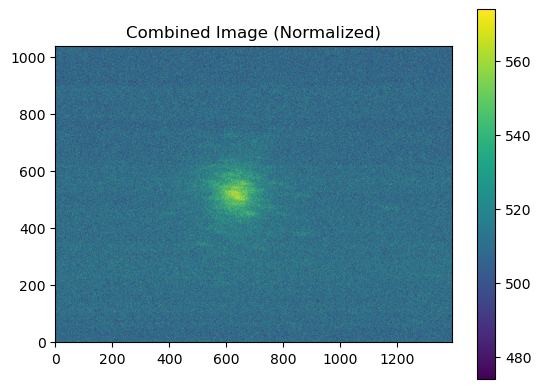

In [11]:
vmin = np.percentile(combined_image, 1)
vmax = vmin + 100  # keeping the range ~100

plt.figure()
plt.imshow(combined_image, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image (Normalized)")
plt.show()

In [12]:
# The combined image is noticeably cleaner and smoother. Taking the median across 5 frames 
# cancels out random noise from hot pixels, cosmic rays, or detector fluctuations that appear 
# in only one or two frames get eliminated because the median ignores extreme values. The 
# star cluster M13 should look sharper, faint stars buried in noise in individual frames 
# become more visible, and the background sky looks more uniform.

In [13]:
fits.writeto("combined.fits", combined_image, overwrite=True)

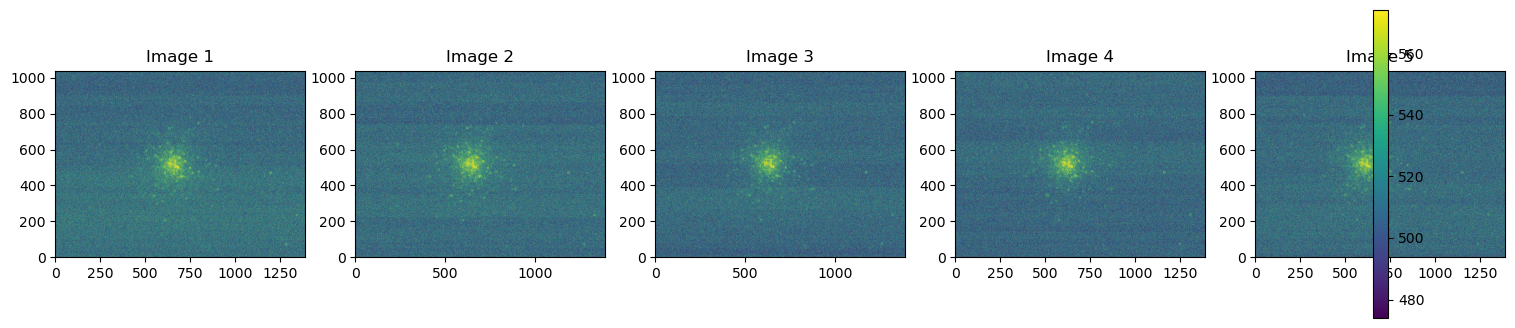

In [14]:
# 3.5 Bonus
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    im = ax.imshow(fits_data[i], origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(f"Image {i+1}")
plt.colorbar(im, ax=axes.tolist())
plt.subplots_adjust(right=0.85)
plt.show()